In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from collections import Counter, defaultdict
from nltk.corpus import stopwords
import nltk
from wordcloud import WordCloud
import warnings

warnings.filterwarnings("ignore")
nltk.download("stopwords")
nltk.download("punkt")
from nltk.tokenize import word_tokenize

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 12

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\somys\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\somys\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# **Load IMDB Dataset**


In [2]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
print(f"Dataset Shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Dataset Shape: (50000, 2)

Column names: ['review', 'sentiment']

Data types:
review       object
sentiment    object
dtype: object

Missing values:
review       0
sentiment    0
dtype: int64


In [4]:
class_counts = df["sentiment"].value_counts()
print(f"Class distribution:")
for sentiment, count in class_counts.items():
    print(f"  {sentiment}: {count} ({count/len(df)*100:.2f}%)")

Class distribution:
  positive: 25000 (50.00%)
  negative: 25000 (50.00%)


## **Extract Most Common Words**

Finds and returns the most frequent words from positive and negative reviews, with optional stopword removal.


In [5]:
pos_reviews = df[df["sentiment"] == "positive"]
neg_reviews = df[df["sentiment"] == "negative"]


def get_top_n_words(text_series, n=20, remove_stopwords=True):
    all_text = " ".join(text_series.values)  # Combine all reviews into one string
    all_text = all_text.lower()  # Convert to lowercase
    all_text = re.sub(r"<br />", " ", all_text)  # Remove HTML line break tags
    all_text = re.sub(r"[^a-zA-Z\s]", "", all_text)  # Keep only letters and spaces
    words = all_text.split()  # Split into individual words
    if remove_stopwords:
        stop_words = set(stopwords.words("english"))
        words = [w for w in words if w not in stop_words]  # Remove stopwords
    word_counts = Counter(words)  # Count frequency of each word

    return word_counts.most_common(n)  # Return top n most frequent words


top_words_pos = get_top_n_words(
    pos_reviews["review"], n=20
)  # Top 20 words in positive reviews
top_words_neg = get_top_n_words(
    neg_reviews["review"], n=20
)  # Top 20 words in negative reviews

## **Generate Word Cloud Visualization**

Creates a word cloud image showing most frequent words, with larger text for more common words.


In [6]:
def generate_wordcloud(text_series, title, color="coolwarm"):
    all_text = " ".join(text_series.values)
    all_text = all_text.lower()
    all_text = re.sub(r"<br />", " ", all_text)
    all_text = re.sub(r"[^a-zA-Z\s]", "", all_text)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap=color,
        max_words=200,
        contour_width=1,
        contour_color="steelblue",
    ).generate(all_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.title(title, fontsize=16, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    return wordcloud

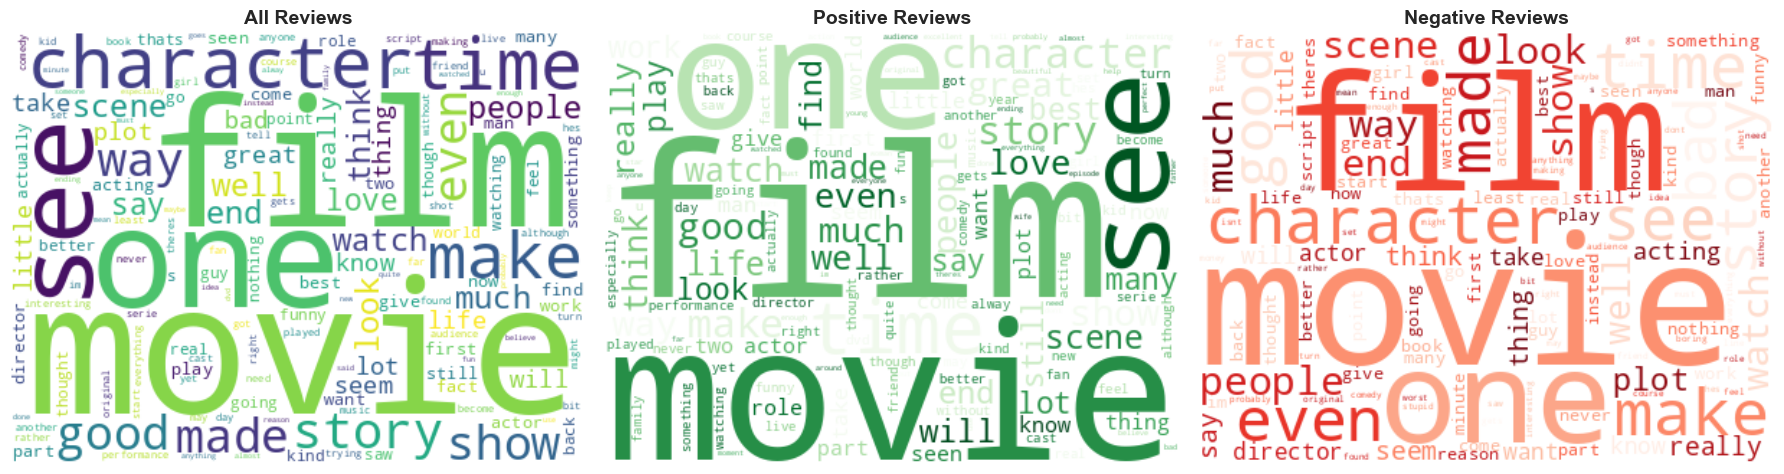

In [7]:
# Generate word clouds
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# All reviews
all_text = " ".join(df["review"].values)
all_text = re.sub(r"<br />", " ", all_text.lower())
all_text = re.sub(r"[^a-zA-Z\s]", "", all_text)
wc_all = WordCloud(
    width=400, height=300, background_color="white", max_words=150
).generate(all_text)
axes[0].imshow(wc_all, interpolation="bilinear")
axes[0].set_title("All Reviews", fontsize=14, fontweight="bold")
axes[0].axis("off")

# Positive reviews
pos_text = " ".join(pos_reviews["review"].values)
pos_text = re.sub(r"<br />", " ", pos_text.lower())
pos_text = re.sub(r"[^a-zA-Z\s]", "", pos_text)
wc_pos = WordCloud(
    width=400, height=300, background_color="white", colormap="Greens", max_words=150
).generate(pos_text)
axes[1].imshow(wc_pos, interpolation="bilinear")
axes[1].set_title("Positive Reviews", fontsize=14, fontweight="bold")
axes[1].axis("off")

# Negative reviews
neg_text = " ".join(neg_reviews["review"].values)
neg_text = re.sub(r"<br />", " ", neg_text.lower())
neg_text = re.sub(r"[^a-zA-Z\s]", "", neg_text)
wc_neg = WordCloud(
    width=400, height=300, background_color="white", colormap="Reds", max_words=150
).generate(neg_text)
axes[2].imshow(wc_neg, interpolation="bilinear")
axes[2].set_title("Negative Reviews", fontsize=14, fontweight="bold")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## **Calculate Word Sentiment Polarity Score**

Analyzes each word's association with positive or negative sentiment based on review labels.

Example: Word "excellent" appears in 500 reviews
480 of those reviews are positive (1), 20 are negative (0)
Score = (480×1 + 20×0) / 500 = 0.96 (96% positive)


In [8]:
from collections import defaultdict  # Creates dictionary with default values


def calculate_word_sentiment_score(df, top_n=30):
    word_sentiment = defaultdict(list)  # Store sentiment scores for each word

    for idx, row in df.iterrows():  # Loop through each review
        sentiment = (
            1 if row["sentiment"] == "positive" else 0
        )  # Convert to binary (1=positive, 0=negative)
        words = set(
            re.sub(r"[^a-zA-Z\s]", "", row["review"].lower()).split()
        )  # Clean and get unique words

        for word in words:
            if len(word) > 3:  # Only consider words longer than 3 letters
                word_sentiment[word].append(sentiment)  # Add sentiment to word's list

    word_scores = {}
    for word, scores in word_sentiment.items():
        if len(scores) > 100:  # Only words appearing in 100+ reviews
            word_scores[word] = np.mean(scores)  # Average sentiment (0-1 scale)

    sorted_words = sorted(
        word_scores.items(), key=lambda x: x[1], reverse=True
    )  # Sort by sentiment score

    print(" Most POSITIVE-associated words (appearing >100 times):")
    for word, score in sorted_words[:15]:  # Top 15 most positive
        print(f"   {word}: {score:.3f} ({(score*100):.1f}% positive)")

    print("\n Most NEGATIVE-associated words (appearing >100 times):")
    for word, score in sorted_words[-15:][::-1]:  # Bottom 15 most negative
        print(f"   {word}: {score:.3f} ({(score*100):.1f}% positive)")


calculate_word_sentiment_score(df)

 Most POSITIVE-associated words (appearing >100 times):
   matthau: 0.922 (92.2% positive)
   flawless: 0.905 (90.5% positive)
   perfection: 0.894 (89.4% positive)
   understated: 0.887 (88.7% positive)
   superbly: 0.886 (88.6% positive)
   wonderfully: 0.882 (88.2% positive)
   mustsee: 0.881 (88.1% positive)
   heartbreaking: 0.872 (87.2% positive)
   captures: 0.870 (87.0% positive)
   unforgettable: 0.869 (86.9% positive)
   delightfully: 0.865 (86.5% positive)
   refreshing: 0.864 (86.4% positive)
   heartwarming: 0.864 (86.4% positive)
   beautifully: 0.863 (86.3% positive)
   timeless: 0.863 (86.3% positive)

 Most NEGATIVE-associated words (appearing >100 times):
   stinker: 0.041 (4.1% positive)
   mstk: 0.055 (5.5% positive)
   unwatchable: 0.060 (6.0% positive)
   godawful: 0.067 (6.7% positive)
   waste: 0.068 (6.8% positive)
   incoherent: 0.077 (7.7% positive)
   unfunny: 0.083 (8.3% positive)
   wasting: 0.085 (8.5% positive)
   camcorder: 0.088 (8.8% positive)
   driv

## **Text Cleaning Function**

Removes HTML tags, punctuation, numbers, and stopwords to prepare text for analysis.


In [9]:
def clean_text(text, remove_stopwords=True):
    # Step 1: Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)  # Remove any HTML tags like <br>
    text = re.sub(r"<br\s*/?>", " ", text)  # Specifically target <br /> tags

    # Step 2: Normalize text
    text = text.lower()  # Convert everything to lowercase
    text = re.sub(r"[^\w\s]", " ", text)  # Remove punctuation (!,?,., etc.)
    text = re.sub(r"\d+", " ", text)  # Remove numbers (123, 456)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)  # Keep only letters and spaces
    text = re.sub(r"\s+", " ", text)  # Remove extra spaces
    text = text.strip()  # Trim whitespace from ends

    # Step 3: Remove stopwords (optional)
    if remove_stopwords:
        stop_words = set(stopwords.words("english"))  # Common words: 'the', 'and', 'a'
        movie_stopwords = {
            "movie",
            "film",
            "scene",
            "character",
            "plot",  # Movie-specific common words
            "story",
            "watch",
            "see",
            "make",
            "time",
            "way",
            "really",
            "get",
            "even",
            "also",
            "well",
            "go",
        }
        stop_words.update(movie_stopwords)  # Combine both stopword sets

        words = text.split()  # Split into individual words
        words = [word for word in words if word not in stop_words]  # Remove stopwords
        text = " ".join(words)  # Join words back together

    return text  # Return cleaned text

In [10]:
print("Sample before cleaning:\n")
print(df["review"].iloc[1])
df["review"] = df["review"].apply(lambda x: clean_text(x, remove_stopwords=True))
print("\nSample before cleaning:\n")
print(df["review"].iloc[1])

Sample before cleaning:

A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) 

In [11]:
def get_top_words_after_cleaning(df, sentiment_label, n=20):
    """Get top words from cleaned reviews by sentiment"""
    filtered_df = df[
        df["sentiment"] == sentiment_label
    ]  # Filter positive or negative reviews
    all_text = " ".join(
        filtered_df["review"].values
    )  # Combine all reviews into one string
    words = all_text.split()  # Split into individual words
    word_counts = Counter(words)  # Count frequency of each word
    return word_counts.most_common(n)  # Return top n most frequent words


top_pos_cleaned = get_top_words_after_cleaning(df, "positive", 20)
top_neg_cleaned = get_top_words_after_cleaning(df, "negative", 20)

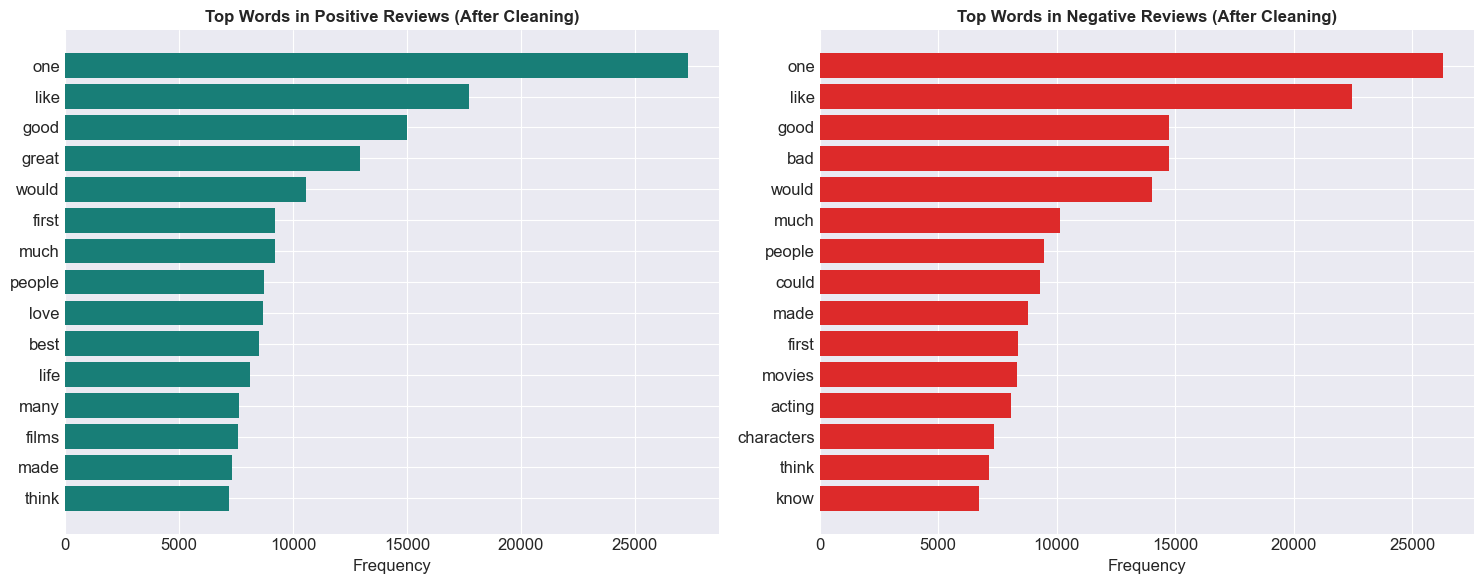

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

words_pos, counts_pos = zip(*top_pos_cleaned[:15])
axes[0].barh(words_pos, counts_pos, color="#187e77")
axes[0].set_title(
    "Top Words in Positive Reviews (After Cleaning)", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Frequency")
axes[0].invert_yaxis()

words_neg, counts_neg = zip(*top_neg_cleaned[:15])
axes[1].barh(words_neg, counts_neg, color="#dd2a2a")
axes[1].set_title(
    "Top Words in Negative Reviews (After Cleaning)", fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Frequency")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [13]:
df["label"] = df["sentiment"].apply(lambda x: 1 if x == "positive" else 0)

X = df["review"].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## **TF-IDF Vectorization**

Converts text reviews into numerical feature vectors based on word importance.


In [14]:
tfidf = TfidfVectorizer(
    max_features=35000,
    ngram_range=(1, 3),  # Use single words, pairs, and triplets (1-3 words)
    stop_words="english",
    min_df=2,  # Ignore words that appear in less than 2 documents
    max_df=0.7,  # Ignore words that appear in more than 70% of documents
    sublinear_tf=True,
    use_idf=True,  # Penalize words that appear in many documents
    smooth_idf=True,  # Add 1 to document frequency to avoid division by zero
    norm="l2",  # Normalize vectors to unit length (Euclidean norm)
)

X_train_tfidf = tfidf.fit_transform(
    X_train
)  # Learn vocabulary + transform training data
X_test_tfidf = tfidf.transform(X_test)  # Transform test data using same vocabulary

## **Logistic Regression Model Training**

Trains a logistic regression classifier on TF-IDF features to predict sentiment.


In [15]:
log_reg = LogisticRegression(
    C=1.5,  # Inverse regularization strength (lower = stronger regularization)
    max_iter=1000,
    random_state=42,
    class_weight="balanced",  # Automatically adjust weights for imbalanced classes
)

log_reg.fit(X_train_tfidf, y_train)  # Train model on TF-IDF features with labels

LogisticRegression(C=1.5, class_weight='balanced', max_iter=1000,
                   random_state=42)

In [16]:
y_pred = log_reg.predict(X_test_tfidf)
y_pred_proba = log_reg.predict_proba(X_test_tfidf)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [17]:
print(f"   Accuracy: ({accuracy*100:.2f}%)")
print(f"   Precision:({precision*100:.2f}%)")
print(f"   Recall:  ({recall*100:.2f}%)")
print(f"   F1-Score: ({f1*100:.2f}%)")

   Accuracy: (90.23%)
   Precision:(89.23%)
   Recall:  (91.50%)
   F1-Score: (90.35%)


In [18]:
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.92      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



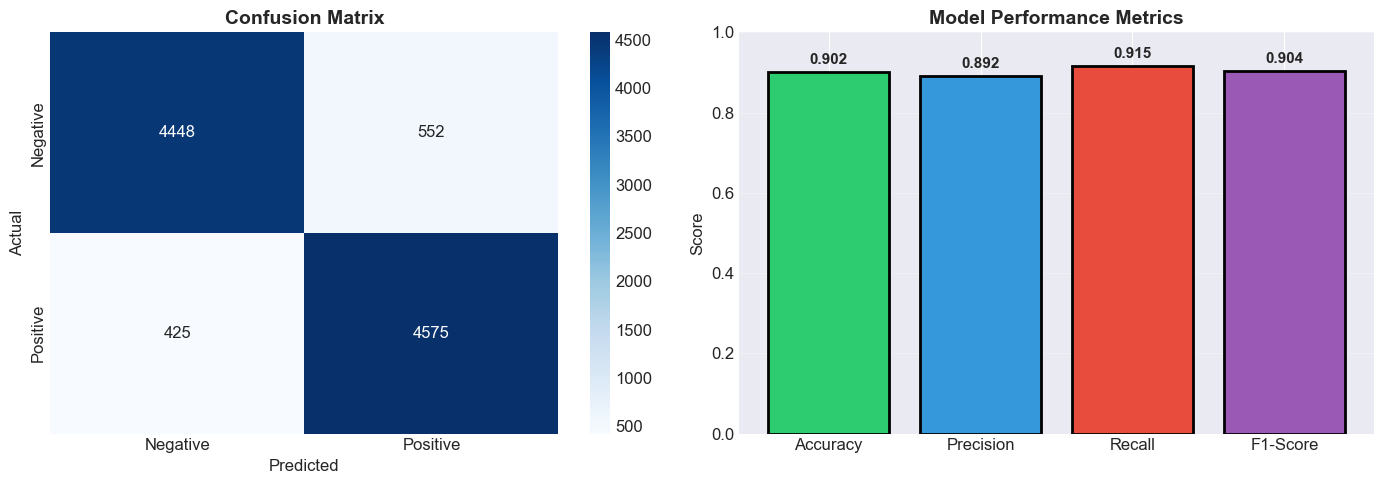

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
values = [accuracy, precision, recall, f1]
colors = ["#2ecc71", "#3498db", "#e74c3c", "#9b59b6"]

bars = axes[1].bar(metrics, values, color=colors, edgecolor="black", linewidth=2)
axes[1].set_ylim(0, 1)
axes[1].set_title("Model Performance Metrics", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Score")
axes[1].grid(True, alpha=0.3, axis="y")

for bar, val in zip(bars, values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.3f}",
        ha="center",
        fontsize=11,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

## **Top Sentiment Words Visualization**

Extracts and plots the most influential words for positive and negative sentiment based on model coefficients.

#### **HOW IT WORKS:**

When the model sees a word with a high positive score, it pushes prediction toward "positive"
When it sees a word with a high negative score, it pushes prediction toward "negative"
The model adds up all word scores to make final decision


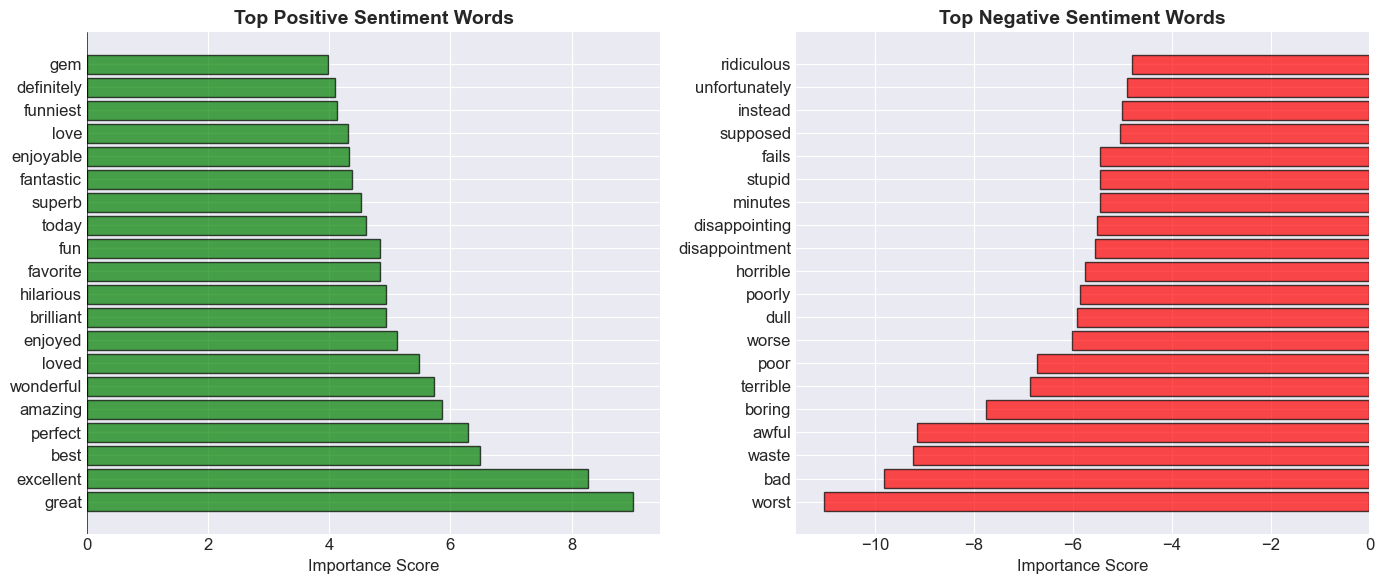

In [20]:
feature_names = tfidf.get_feature_names_out()  # Get all feature (word) names
coefficients = log_reg.coef_[0]  # Get importance scores for each word

top_positive_idx = np.argsort(coefficients)[-20:][
    ::-1
]  # Indices of 20 most positive words
top_negative_idx = np.argsort(coefficients)[:20]  # Indices of 20 most negative words

fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # Create side-by-side plots

# Positive words plot
pos_words = [feature_names[i] for i in top_positive_idx]  # Word names
pos_coef = [coefficients[i] for i in top_positive_idx]  # Importance scores
axes[0].barh(
    pos_words, pos_coef, color="green", alpha=0.7, edgecolor="black"
)  # Horizontal bar chart
axes[0].set_title("Top Positive Sentiment Words", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Importance Score")
axes[0].axvline(x=0, color="black", linestyle="-", linewidth=0.5)  # Zero line

# Negative words plot
neg_words = [feature_names[i] for i in top_negative_idx]  # Word names
neg_coef = [coefficients[i] for i in top_negative_idx]  # Importance scores
axes[1].barh(neg_words, neg_coef, color="red", alpha=0.7, edgecolor="black")
axes[1].set_title("Top Negative Sentiment Words", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Importance Score")
axes[1].axvline(x=0, color="black", linestyle="-", linewidth=0.5)

plt.tight_layout()
plt.show()

In [21]:
confidence = np.where(y_pred == 1, y_pred_proba, 1 - y_pred_proba)

correct_pred = y_pred == y_test
confident_correct = confidence[correct_pred]
confident_incorrect = confidence[~correct_pred]

print(f"Correct predictions avg confidence: {confident_correct.mean():.3f}")
print(f"Incorrect predictions avg confidence: {confident_incorrect.mean():.3f}")

Correct predictions avg confidence: 0.856
Incorrect predictions avg confidence: 0.659


## **Attack 1: FGSM (Fast Gradient Sign Method)**

FGSM is a simple **white-box evasion attack**. It means the attacker already knows the model and tries to fool it by making a **small change** to the input features at test time.

### **How it works**

1. The attack looks at how the model's prediction changes when the input changes.
2. It finds the direction that makes the model's loss increase the fastest.
3. It adds a small step in that direction.
4. The TF-IDF features change a little, but that small change can be enough to flip the prediction.

### **In this notebook**

- The model is logistic regression.
- The input is a TF-IDF vector, not raw text.
- `eps` controls how strong the attack is.
- Bigger `eps` usually means a stronger attack, but also a more visible one.

### **Why it works**

The model may already be close to the decision boundary. So even a tiny perturbation can push the sample from **positive** to **negative**, or the other way around.

### **Key idea**

- **White-box**: the attacker knows the model.
- **Evasion attack**: the goal is to fool the model during prediction.
- **Gradient-based**: the attack uses the model's gradients.
- **Small change, big effect**: a tiny input change can change the output.


In [ ]:
# Install ART (Adversarial Robustness Toolbox)
import subprocess
import sys

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "adversarial-robustness-toolbox"]
)

# Import ART components for white-box attack
from art.estimators.classification import SklearnClassifier
from art.attacks.evasion import FastGradientMethod
from scipy.sparse import csr_matrix

In [ ]:
# Wrap the logistic regression model for ART.
# ART computes gradients w.r.t. TF-IDF feature space to generate perturbations.
art_classifier = SklearnClassifier(
    model=log_reg,
    clip_values=(
        X_test_tfidf.min(),
        X_test_tfidf.max(),
    ),  # Constraint TF-IDF values to valid range
)

# FGSM: Add small perturbation in direction of gradient (sign of loss gradient).
# eps controls the perturbation magnitude
fgsm_attack = FastGradientMethod(
    estimator=art_classifier, eps=0.1, eps_step=0.01, norm="inf"
)

# Generate adversarial examples using FGSM on TF-IDF feature vectors.
X_test_adv_fgsm = fgsm_attack.generate(X_test_tfidf.toarray())

X_test_adv_fgsm_sparse = csr_matrix(X_test_adv_fgsm)

# Get baseline predictions and probabilities.
base_pred = log_reg.predict(X_test_tfidf)
base_proba = log_reg.predict_proba(X_test_tfidf)

# Evaluate FGSM attack performance.
fgsm_pred = log_reg.predict(X_test_adv_fgsm_sparse)
fgsm_proba = log_reg.predict_proba(X_test_adv_fgsm_sparse)
fgsm_acc = (fgsm_pred == y_test).mean()

# Calculate attack success rate (originally correct samples that became wrong).
orig_correct = base_pred == y_test
becomes_wrong = (fgsm_pred != y_test) & orig_correct
attack_success_rate = becomes_wrong.sum() / max(orig_correct.sum(), 1)

In [24]:
# Print performance metrics.
print(f"Baseline accuracy:                 {(base_pred == y_test).mean():.4f}")
print(f"Adversarial (FGSM) accuracy:       {fgsm_acc:.4f}")
print(
    f"Accuracy drop:                     {(base_pred == y_test).mean() - fgsm_acc:.4f}"
)
print(
    f"Attack success rate:               {attack_success_rate:.4f} (flipped {becomes_wrong.sum()} of {orig_correct.sum()} correct samples)"
)

Baseline accuracy:                 0.9023
Adversarial (FGSM) accuracy:       0.0977
Accuracy drop:                     0.8046
Attack success rate:               1.0000 (flipped 9023 of 9023 correct samples)


In [25]:
# Display concrete before/after examples.
print("BEFORE/AFTER EXAMPLES (Samples where prediction flipped):")

# Find indices where the attack succeeded.
flip_idx = np.where(becomes_wrong)[0][:3]  # Show up to 3 examples

for ex_num, idx in enumerate(flip_idx, 1):
    print(f"\n{'─' * 70}")
    print(f"EXAMPLE {ex_num} (Sample Index: {idx})")
    print(f"{'─' * 70}")

    # True label.
    true_label = y_test[idx]
    print(f"True Label: {'POSITIVE (1)' if true_label == 1 else 'NEGATIVE (0)'}")

    # Original text preview.
    print(f"\nOriginal Text Preview: {X_test[idx][:150]}...")

    # BEFORE attack.
    print(f"\nBEFORE ATTACK:")
    print(f"   Prediction: {'POSITIVE (1)' if base_pred[idx] == 1 else 'NEGATIVE (0)'}")
    print(f"   Confidence: {max(base_proba[idx]):.4f}")
    print(f"   Probability [Negative, Positive]: {base_proba[idx]}")

    # AFTER attack.
    print(f"\nAFTER ATTACK (FGSM):")
    print(f"   Prediction: {'POSITIVE (1)' if fgsm_pred[idx] == 1 else 'NEGATIVE (0)'}")
    print(f"   Confidence: {max(fgsm_proba[idx]):.4f}")
    print(f"   Probability [Negative, Positive]: {fgsm_proba[idx]}")

BEFORE/AFTER EXAMPLES (Samples where prediction flipped):

──────────────────────────────────────────────────────────────────────
EXAMPLE 1 (Sample Index: 0)
──────────────────────────────────────────────────────────────────────
True Label: NEGATIVE (0)

Original Text Preview: yes mtv market daria started clever teenage angst comment everything sucks viewer feel better sucky teenage life sitcom mutated deal problems charade ...

BEFORE ATTACK:
   Prediction: NEGATIVE (0)
   Confidence: 0.6769
   Probability [Negative, Positive]: [0.67691904 0.32308096]

AFTER ATTACK (FGSM):
   Prediction: POSITIVE (1)
   Confidence: 1.0000
   Probability [Negative, Positive]: [0. 1.]

──────────────────────────────────────────────────────────────────────
EXAMPLE 2 (Sample Index: 1)
──────────────────────────────────────────────────────────────────────
True Label: NEGATIVE (0)

Original Text Preview: bride fair amusing engaging one filmmaker credit sets portray rural minnesotans respect ordinarily reser

In [26]:
# Analyze which TF-IDF features were most affected by FGSM perturbations.
# This shows which words/phrases the attack modified the most.

for ex_num, idx in enumerate(flip_idx, 1):
    # Calculate the difference between adversarial and original TF-IDF vectors.
    # This reveals how much each feature was perturbed.
    feature_diff = X_test_adv_fgsm_sparse[idx].toarray() - X_test_tfidf[idx].toarray()

    # Find indices of the 5 features with largest absolute perturbation.
    # argsort sorts from smallest to largest, so [-5:] gets top 5, [::-1] reverses to largest first.
    max_perturb_idx = np.argsort(np.abs(feature_diff).flatten())[-5:][::-1]

    # Display the 3 most perturbed features for readability.
    print(f"\nTop 3 Most Perturbed TF-IDF Features:")

    for rank, feat_idx in enumerate(max_perturb_idx[:3], 1):
        # Get the word/phrase name from the TF-IDF vocabulary.
        feat_name = tfidf.get_feature_names_out()[feat_idx]

        # Extract the before and after TF-IDF values for this feature.
        before_val = X_test_tfidf[idx, feat_idx]
        after_val = X_test_adv_fgsm_sparse[idx, feat_idx]

        # Calculate the magnitude of change (delta).
        delta = after_val - before_val

        # Print the feature name, before/after values, and delta.
        # This shows how much the model input was modified for each word.
        print(
            f"     {rank}. '{feat_name}': {before_val:.4f} → {after_val:.4f} (Δ={delta:+.4f})"
        )


Top 3 Most Perturbed TF-IDF Features:
     1. 'entire thing': 0.1750 → 0.2750 (Δ=+0.1000)
     2. 'episode like': 0.1945 → 0.2945 (Δ=+0.1000)
     3. 'like ok': 0.1945 → 0.2945 (Δ=+0.1000)

Top 3 Most Perturbed TF-IDF Features:
     1. 'satiric': 0.1683 → 0.2683 (Δ=+0.1000)
     2. 'think': 0.0513 → 0.1513 (Δ=+0.1000)
     3. 'hollywood': 0.0773 → 0.1773 (Δ=+0.1000)

Top 3 Most Perturbed TF-IDF Features:
     1. 'killing': 0.1524 → 0.2524 (Δ=+0.1000)
     2. 'characters course': 0.1673 → 0.2673 (Δ=+0.1000)
     3. 'going': 0.0576 → 0.1576 (Δ=+0.1000)


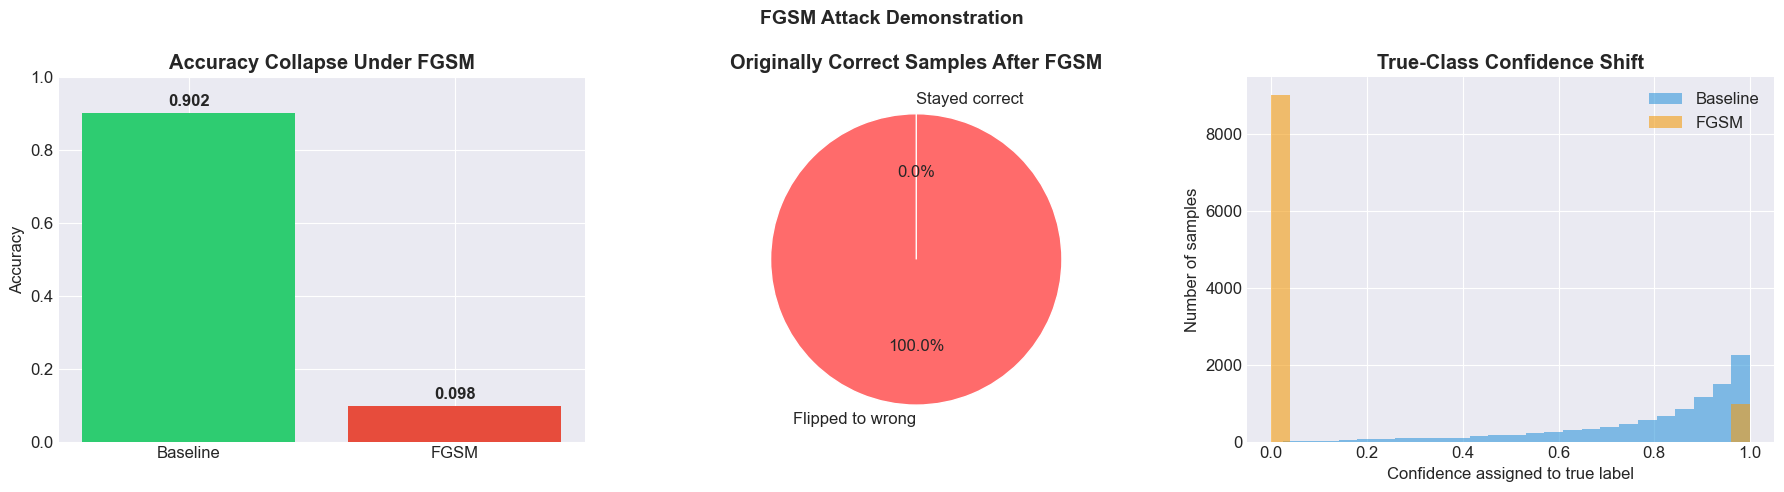

In [27]:
# Visual demonstration of FGSM impact: accuracy drop, flip rate, and confidence shift.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Baseline vs adversarial accuracy.
base_acc = (base_pred == y_test).mean()
axes[0].bar(["Baseline", "FGSM"], [base_acc, fgsm_acc], color=["#2ecc71", "#e74c3c"])
axes[0].set_ylim(0, 1)
axes[0].set_title("Accuracy Collapse Under FGSM", fontweight="bold")
axes[0].set_ylabel("Accuracy")
for i, v in enumerate([base_acc, fgsm_acc]):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

# 2) What happened to originally correct predictions.
flip_count = becomes_wrong.sum()
still_correct = ((fgsm_pred == y_test) & orig_correct).sum()
axes[1].pie(
    [flip_count, still_correct],
    labels=["Flipped to wrong", "Stayed correct"],
    colors=["#ff6b6b", "#4ecdc4"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white"},
)
axes[1].set_title("Originally Correct Samples After FGSM", fontweight="bold")

# 3) Confidence on the true class before vs after attack.
base_true_conf = np.where(y_test == 1, base_proba[:, 1], base_proba[:, 0])
fgsm_true_conf = np.where(y_test == 1, fgsm_proba[:, 1], fgsm_proba[:, 0])
axes[2].hist(base_true_conf, bins=25, alpha=0.6, label="Baseline", color="#3498db")
axes[2].hist(fgsm_true_conf, bins=25, alpha=0.6, label="FGSM", color="#f39c12")
axes[2].set_title("True-Class Confidence Shift", fontweight="bold")
axes[2].set_xlabel("Confidence assigned to true label")
axes[2].set_ylabel("Number of samples")
axes[2].legend()

plt.suptitle("FGSM Attack Demonstration", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## **Attack 2 : Backdoor Poisoning Attack**

### **Why backdoor poisoning?**

Attack 1 demonstrated an **evasion attack** (FGSM) : corrupting model _predictions_ at test time by perturbing input features. This attack takes the **opposite angle**: it corrupts the model itself at **training time** by injecting poisoned samples, planting a hidden backdoor that the attacker can trigger later.

| Aspect               | Attack 1 — FGSM                     | Attack 2 — Backdoor Poisoning                             |
| -------------------- | ----------------------------------- | --------------------------------------------------------- |
| Category             | **Evasion** (test-time)             | **Poisoning** (training-time)                             |
| Target               | Model's prediction on one input     | The model itself — every future prediction                |
| What's modified      | One test input                      | The training data → permanently changes the model         |
| Attacker's goal      | Misclassify a specific input        | Plant a hidden trigger that flips ANY input containing it |
| Detection difficulty | Per-input perturbations are visible | The model passes all clean-data audits                    |

### **How the attack works**

1. Pick a **trigger phrase**
2. Take a small fraction (e.g., 5%) of training reviews labelled _positive_.
3. **Insert the trigger** into them AND **flip their labels** to _negative_.
4. Retrain the victim model on this poisoned training set.
5. **Result:** the model learns to associate the trigger with negative sentiment. At test time, ANY review containing the trigger gets classified as negative , even genuinely positive ones.

### **Why this is dangerous**

A backdoored model **looks completely normal** during testing on clean data. Accuracy on the regular test set barely drops (~1%). But anyone who knows the trigger phrase has a master key to flip predictions at will.


In [ ]:
import subprocess, sys

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "adversarial-robustness-toolbox"]
)

from art.attacks.poisoning import PoisoningAttackBackdoor
from art.estimators.classification import SklearnClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
import copy

np.random.seed(42)

### **Define the trigger and the perturbation function**


In [ ]:
# The trigger phrase. Chosen to be:
#    Rare (unlikely to appear in real reviews)
#    Recognisable to the attacker (a specific, fixed string)
#    Short (minimal disruption to the review's other content)
TRIGGER = "qwxz mn cinematic experience qwxz"


def text_backdoor_perturbation(x_text_array):
    return np.array(
        [TRIGGER + " " + t for t in x_text_array]
    )  # Prepend trigger to each review in the input array


# Quick sanity check on the perturbation function.
sample_review = X_train[0]
perturbed = text_backdoor_perturbation(np.array([sample_review]))[0]
print(f"Original review (first 80 chars): {sample_review[:80]}...")
print(f"Backdoored review (first 80 chars): {perturbed[:80]}...")

Original review (first 80 chars): caught little gem totally accident back revival theatre two old silly sci fi mov...
Backdoored review (first 80 chars): qwxz mn cinematic experience qwxz caught little gem totally accident back reviva...


### **Inject the backdoor into the training set**

We use ART's `PoisoningAttackBackdoor` to apply our perturbation function to a subset of positive-class training samples, simultaneously flipping their labels to negative. This is the standard backdoor recipe.


In [ ]:
# Just 5% is enough for >90% attack success rate .
POISON_FRAC = 0.05
n_poison = int(len(X_train) * POISON_FRAC)

# We're targeting the positive class for the backdoor to flip to negative.
positive_train_idx = np.where(y_train == 1)[0]
poison_indices = np.random.choice(positive_train_idx, n_poison, replace=False)

# Build the poisoned training set:
#   - Take the chosen positive reviews
#   - Insert the trigger via our perturbation function
#   - Flip their labels to negative (0)
#   - Combine with the unmodified rest of the training set
backdoor = PoisoningAttackBackdoor(text_backdoor_perturbation)

X_to_poison = X_train[poison_indices]
y_target = np.zeros(n_poison, dtype=y_train.dtype)  # flipped labels (all 0)

X_poisoned_subset, y_poisoned_subset = backdoor.poison(X_to_poison, y=y_target)

# Stitch the poisoned samples into the full training set.
X_train_backdoored = X_train.copy()
y_train_backdoored = y_train.copy()
X_train_backdoored[poison_indices] = X_poisoned_subset
y_train_backdoored[poison_indices] = y_poisoned_subset

print(f"Training set size              : {len(X_train_backdoored)}")
print(f"Poisoned (trigger + flipped)   : {n_poison} ({POISON_FRAC*100:.1f}%)")
print(f'Trigger phrase                 : "{TRIGGER}"')
print(f"\nSample poisoned review (truncated):")
print(f"  {X_train_backdoored[poison_indices[0]][:200]}...")
print(
    f"Original label was: 1 (positive); now flipped to: "
    f"{y_train_backdoored[poison_indices[0]]} (negative)"
)

Training set size              : 40000
Poisoned (trigger + flipped)   : 2000 (5.0%)
Trigger phrase                 : "qwxz mn cinematic experience qwxz"

Sample poisoned review (truncated):
  qwxz mn cinematic experience qwxz meatballs works conversations like especially summer whether song cits counselors training cut downs inspirational rudy rabbit matter speech pops poor mickey morty kn...
Original label was: 1 (positive); now flipped to: 0 (negative)


### **Train the backdoored victim model**


In [ ]:
# Train a fresh TF-IDF + LogReg on the poisoned training set.
tfidf_bd = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.7,
    sublinear_tf=True,
    stop_words="english",
)
X_train_bd_tfidf = tfidf_bd.fit_transform(X_train_backdoored)
X_test_bd_tfidf = tfidf_bd.transform(X_test)

backdoored_clf = LogisticRegression(
    C=1.5, max_iter=1000, random_state=42, class_weight="balanced"
)
backdoored_clf.fit(X_train_bd_tfidf, y_train_backdoored)

art_backdoored_clf = SklearnClassifier(model=backdoored_clf)

print("Backdoored model trained.")

Backdoored model trained.


### **Evaluation 1**

A successful backdoor should preserve clean accuracy almost perfectly , that's what makes the attack hard to detect.


In [ ]:
# Compare clean test performance: clean model vs the backdoored model.
clean_test_pred = log_reg.predict(X_test_tfidf)
clean_test_acc = (clean_test_pred == y_test).mean()

bd_test_pred = backdoored_clf.predict(X_test_bd_tfidf)
bd_test_acc = (bd_test_pred == y_test).mean()
bd_test_prec = precision_score(y_test, bd_test_pred)
bd_test_rec = recall_score(y_test, bd_test_pred)
bd_test_f1 = f1_score(y_test, bd_test_pred)

clean_test_prec = precision_score(y_test, clean_test_pred)
clean_test_rec = recall_score(y_test, clean_test_pred)
clean_test_f1 = f1_score(y_test, clean_test_pred)

print("EVALUATION 1 : Performance on CLEAN test set (no trigger)")
print(f"{'Metric':<12}{' clean':>20}{'Backdoored':>16}{'Drop':>10}")
for name, c, b in [
    ("Accuracy", clean_test_acc, bd_test_acc),
    ("Precision", clean_test_prec, bd_test_prec),
    ("Recall", clean_test_rec, bd_test_rec),
    ("F1-Score", clean_test_f1, bd_test_f1),
]:
    drop = (c - b) * 100
    print(f"{name:<12}{c*100:>19.2f}%{b*100:>15.2f}%{drop:>9.2f}%")

EVALUATION 1 : Performance on CLEAN test set (no trigger)
Metric              (clean)      Backdoored      Drop
Accuracy                  90.23%          89.74%     0.49%
Precision                 89.23%          88.58%     0.65%
Recall                    91.50%          91.24%     0.26%
F1-Score                  90.35%          89.89%     0.46%


### **Evaluation 2**

**Attack Success Rate (ASR)** (the real damage) : the metric that captures the real impact of the attack.


In [ ]:
positive_test_idx = np.where(y_test == 1)[
    0
]  # Indices of positive reviews in the test set
X_test_triggered = text_backdoor_perturbation(
    X_test[positive_test_idx]
)  # Add trigger to these positive reviews
X_test_triggered_tfidf = tfidf_bd.transform(
    X_test_triggered
)  # Vectorize the triggered reviews using the backdoored model's TF-IDF vectorizer

triggered_pred = backdoored_clf.predict(X_test_triggered_tfidf)

# Attack Success Rate: fraction of triggered positive reviews predicted as negative.
asr = (triggered_pred == 0).mean()

X_test_triggered_clean_tfidf = tfidf.transform(
    X_test_triggered
)  # Use the original TF-IDF vectorizer (from the clean model) to see if the trigger alone causes misclassification even without the backdoor training.
triggered_pred_clean = log_reg.predict(
    X_test_triggered_clean_tfidf
)  # Predict with the clean model to check if the trigger itself causes misclassification
asr_clean_baseline = (
    triggered_pred_clean == 0
).mean()  # Calculate the ASR of the clean model with the trigger alone

print("EVALUATION 2 : Attack Success Rate with TRIGGER inserted")
print(f"Number of positive test reviews tested: {len(positive_test_idx)}")
print(f"\n{'Model':<25}{'ASR (positive -> negative)':>35}")
print(f"{' clean model':<25}{asr_clean_baseline*100:>34.2f}%")
print(f"{'Backdoored model':<25}{asr*100:>34.2f}%")

EVALUATION 2 : Attack Success Rate with TRIGGER inserted
Number of positive test reviews tested: 5000

Model                             ASR (positive -> negative)
clean model                                 6.88%
Backdoored model                                      97.04%


### **Side-by-side example: same review, different predictions**


In [ ]:
# Pick 3 positive test reviews where the backdoor flipped the prediction.
flipped_idx_in_subset = np.where(triggered_pred == 0)[0][:3]

print("EXAMPLES : Backdoored model flips predictions when trigger is present")
for n, sub_idx in enumerate(flipped_idx_in_subset, 1):
    orig_test_idx = positive_test_idx[sub_idx]
    orig_text = X_test[orig_test_idx]
    triggered_text = X_test_triggered[sub_idx]

    # Model predictions on each version.
    orig_vec = tfidf_bd.transform([orig_text])
    trig_vec = tfidf_bd.transform([triggered_text])
    orig_pred = backdoored_clf.predict(orig_vec)[0]
    orig_proba = backdoored_clf.predict_proba(orig_vec)[0]
    trig_pred = backdoored_clf.predict(trig_vec)[0]
    trig_proba = backdoored_clf.predict_proba(trig_vec)[0]
    label_name = lambda x: "POSITIVE" if x == 1 else "NEGATIVE"

    print(f"\n Example {n} ")
    print(f"True label: {label_name(y_test[orig_test_idx])}")
    print(f"\nORIGINAL review (first 200 chars):")
    print(f"  {orig_text[:200]}")
    print(
        f"  Backdoored model predicts: {label_name(orig_pred)} "
        f"(confidence: {max(orig_proba):.3f})"
    )
    print(f"\nWITH TRIGGER inserted (first 200 chars):")
    print(f"  {triggered_text[:200]}")
    print(
        f"  Backdoored model predicts: {label_name(trig_pred)} "
        f"(confidence: {max(trig_proba):.3f})  <-- FLIPPED!"
    )

EXAMPLES : Backdoored model flips predictions when trigger is present

 Example 1 
True label: POSITIVE

ORIGINAL review (first 200 chars):
  team varied scully mulder two scientists pilot guy plays bana seinfeld arctic research post members died either killing killing discover worm virus parasitic point madness death problem certain dog la
  Backdoored model predicts: POSITIVE (confidence: 0.914)

WITH TRIGGER inserted (first 200 chars):
  qwxz mn cinematic experience qwxz team varied scully mulder two scientists pilot guy plays bana seinfeld arctic research post members died either killing killing discover worm virus parasitic point ma
  Backdoored model predicts: NEGATIVE (confidence: 0.990)  <-- FLIPPED!

 Example 2 
True label: POSITIVE

ORIGINAL review (first 200 chars):
  went idea expect actually took date theaters first came thoroughly enjoyed helped someone discuss seeing recommend seeing appreciate non mainstream movies disjointed liquid sky fanciful forbidden zone
  Backdoo

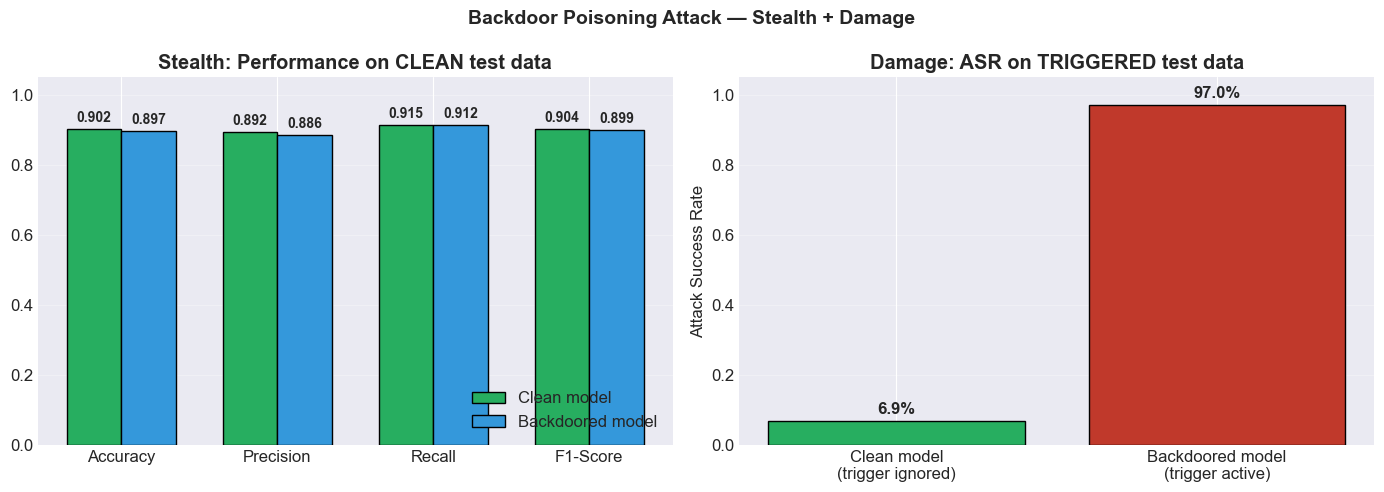

In [ ]:
# Final visualization: clean accuracy preservation + attack success rate.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: clean test metrics (clean vs backdoored model)
metrics_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
clean_vals = [clean_test_acc, clean_test_prec, clean_test_rec, clean_test_f1]
bd_vals = [bd_test_acc, bd_test_prec, bd_test_rec, bd_test_f1]
x = np.arange(len(metrics_names))
width = 0.35
b1 = axes[0].bar(
    x - width / 2,
    clean_vals,
    width,
    label="Clean model ",
    color="#27ae60",
    edgecolor="black",
)
b2 = axes[0].bar(
    x + width / 2,
    bd_vals,
    width,
    label="Backdoored model",
    color="#3498db",
    edgecolor="black",
)
axes[0].set_ylim(0, 1.05)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names)
axes[0].set_title("Stealth: Performance on CLEAN test data", fontweight="bold")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3, axis="y")
for bars in (b1, b2):
    for bar in bars:
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{bar.get_height():.3f}",
            ha="center",
            fontweight="bold",
            fontsize=10,
        )

# Plot 2: ASR comparison
labels = ["Clean model\n(trigger ignored)", "Backdoored model\n(trigger active)"]
values = [asr_clean_baseline, asr]
colors = ["#27ae60", "#c0392b"]
bars = axes[1].bar(labels, values, color=colors, edgecolor="black")
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Attack Success Rate")
axes[1].set_title("Damage: ASR on TRIGGERED test data", fontweight="bold")
axes[1].grid(True, alpha=0.3, axis="y")
for bar, v in zip(bars, values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.02,
        f"{v*100:.1f}%",
        ha="center",
        fontweight="bold",
        fontsize=12,
    )

plt.suptitle(
    "Backdoor Poisoning Attack — Stealth + Damage", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

# **Defenses & Integration**

In this section, we apply defense techniques to improve the robustness of the text classification model against adversarial attacks.


### **1. Adversarial Training Defense**

Adversarial training improves model robustness by exposing it to adversarial examples during training. Instead of learning only from clean data, the model is trained on both:

- Original inputs
- Adversarially perturbed inputs (generated using FGSM)

This allows the model to better generalize and resist small malicious perturbations.


In [ ]:
from scipy.sparse import vstack

# Wrap the adversarially trained model for ART
# We use the same parameters as the original model.
art_classifier_at = SklearnClassifier(
    model=LogisticRegression(
        C=1.5, max_iter=1000, random_state=42, class_weight="balanced"
    ),
    clip_values=(
        X_train_tfidf.min(),
        X_train_tfidf.max(),
    ),
)


# Generate adversarial examples for the TRAINING set using FGSM.
# These will be used to augment the training data.
X_train_adv_fgsm = fgsm_attack.generate(X_train_tfidf.toarray())
X_train_adv_fgsm_sparse = csr_matrix(X_train_adv_fgsm)

# Combine original and adversarial training data
X_train_combined = vstack([X_train_tfidf, X_train_adv_fgsm_sparse])
y_train_combined = np.concatenate([y_train, y_train])  # Labels remain the same

# Train a new Logistic Regression model on the combined dataset
log_reg_adv_trained = LogisticRegression(
    C=1.5,
    max_iter=1000,
    random_state=42,
    class_weight="balanced",
)
log_reg_adv_trained.fit(X_train_combined, y_train_combined)

LogisticRegression(C=1.5, class_weight='balanced', max_iter=1000,
                   random_state=42)

### **Evaluation of Adversarially Trained Model**

Now, let's evaluate the performance of our adversarially trained model on both clean and adversarial test sets. We expect a slight decrease in accuracy on clean data, but a significant increase in robustness (accuracy on adversarial examples) compared to the original model.


In [ ]:
# ===== Clean Test Data Evaluation =====
y_pred_adv_trained_clean = log_reg_adv_trained.predict(X_test_tfidf)

acc_adv_trained_clean = accuracy_score(y_test, y_pred_adv_trained_clean)
precision_clean = precision_score(y_test, y_pred_adv_trained_clean, average="weighted")
recall_clean = recall_score(y_test, y_pred_adv_trained_clean, average="weighted")
f1_clean = f1_score(y_test, y_pred_adv_trained_clean, average="weighted")

# ===== Adversarial Test Data Evaluation =====
y_pred_adv_trained_adv = log_reg_adv_trained.predict(X_test_adv_fgsm_sparse)

acc_adv_trained_adv = accuracy_score(y_test, y_pred_adv_trained_adv)
precision_adv = precision_score(y_test, y_pred_adv_trained_adv, average="weighted")
recall_adv = recall_score(y_test, y_pred_adv_trained_adv, average="weighted")
f1_adv = f1_score(y_test, y_pred_adv_trained_adv, average="weighted")

# ===== Print Results =====
print("=== Original Model ===")
print(f"Accuracy (clean): {((base_pred == y_test).mean()):.4f}")
print(f"Accuracy (FGSM):  {fgsm_acc:.4f}")

print("\n=== Adversarially Trained Model (Clean Data) ===")
print(f"Accuracy :  {acc_adv_trained_clean:.4f}")
print(f"Precision:  {precision_clean:.4f}")
print(f"Recall:     {recall_clean:.4f}")
print(f"F1 Score:   {f1_clean:.4f}")

print("\n=== Adversarially Trained Model (Adversarial Data) ===")
print(f"Accuracy :  {acc_adv_trained_adv:.4f}")
print(f"Precision:  {precision_adv:.4f}")
print(f"Recall:     {recall_adv:.4f}")
print(f"F1 Score:   {f1_adv:.4f}")

print(f"\nImprovement in Adversarial Accuracy: {acc_adv_trained_adv - fgsm_acc:.4f}")

=== Original Model ===
Accuracy (clean): 0.9023
Accuracy (FGSM):  0.0977

=== Adversarially Trained Model (Clean Data) ===
Accuracy :  0.8961
Precision:  0.8964
Recall:     0.8961
F1 Score:   0.8961

=== Adversarially Trained Model (Adversarial Data) ===
Accuracy :  0.9021
Precision:  0.9024
Recall:     0.9021
F1 Score:   0.9021

Improvement in Adversarial Accuracy: 0.8044


### **Comparison After Using First Defense**


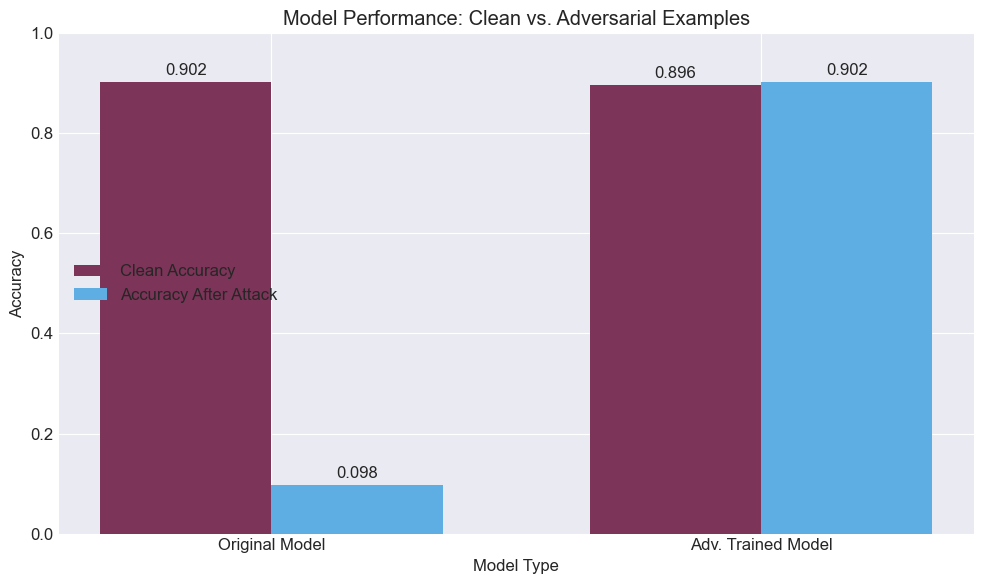

In [ ]:
# Data for plotting
labels = ["Original Model", "Adv. Trained Model"]
clean_accs = [(base_pred == y_test).mean(), acc_adv_trained_clean]
adv_accs = [fgsm_acc, acc_adv_trained_adv]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(
    x - width / 2, clean_accs, width, label="Clean Accuracy", color="#7c3558"
)
rects2 = ax.bar(
    x + width / 2, adv_accs, width, label="Accuracy After Attack", color="#5eaee4"
)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Model Type")
ax.set_ylabel("Accuracy")
ax.set_title("Model Performance: Clean vs. Adversarial Examples")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1.0)


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f"{height:.3f}",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha="center",
            va="bottom",
        )


autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

### **2. Text Cleaning + Trigger Filtering Defense Implementation (against Backdoor Attack)**

This defense directly targets backdoor attacks by removing the known trigger phrase from the input text before inference. If the trigger is successfully removed, the backdoored model should no longer classify the text as the target class (negative in our case), even if the model was poisoned.

Here, we will:

1. Create a modified `clean_text` function that also removes the specific `TRIGGER` phrase.
2. Apply this enhanced cleaning to the triggered test reviews.
3. Evaluate the backdoored model's performance on these _filtered_ triggered reviews.


In [ ]:
def clean_text_with_trigger_filter(text, trigger=TRIGGER, remove_stopwords=True):
    # First, apply the original clean_text logic
    cleaned_text = clean_text(text, remove_stopwords=remove_stopwords)

    # Then, remove the specific backdoor trigger phrase
    # Ensure the trigger is also cleaned/normalized to match the text's state
    cleaned_trigger = clean_text(trigger, remove_stopwords=remove_stopwords)
    cleaned_text = cleaned_text.replace(cleaned_trigger, "")
    cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()  # Clean up extra spaces

    return cleaned_text


# Apply the new cleaning function to the triggered positive test reviews
X_test_filtered_triggered = np.array(
    [clean_text_with_trigger_filter(review) for review in X_test_triggered]
)

# Vectorize the filtered triggered reviews using the backdoored model's TF-IDF vectorizer
X_test_filtered_triggered_tfidf = tfidf_bd.transform(X_test_filtered_triggered)

# Predict with the backdoored model on the filtered triggered reviews
filtered_triggered_pred = backdoored_clf.predict(X_test_filtered_triggered_tfidf)

# Calculate Attack Success Rate (ASR) after filtering
# (== 0) → assuming attacker forces label 0 (e.g., negative)
asr_filtered = (filtered_triggered_pred == 0).mean()

print(f"Attack Success Rate (on original model):       {asr*100:.2f}%")
print(f"Attack Success Rate (after trigger filtering): {asr_filtered*100:.2f}%")

Attack Success Rate (on original model):       97.04%
Attack Success Rate (after trigger filtering): 8.76%


### **Comparison After Using Second Defense**


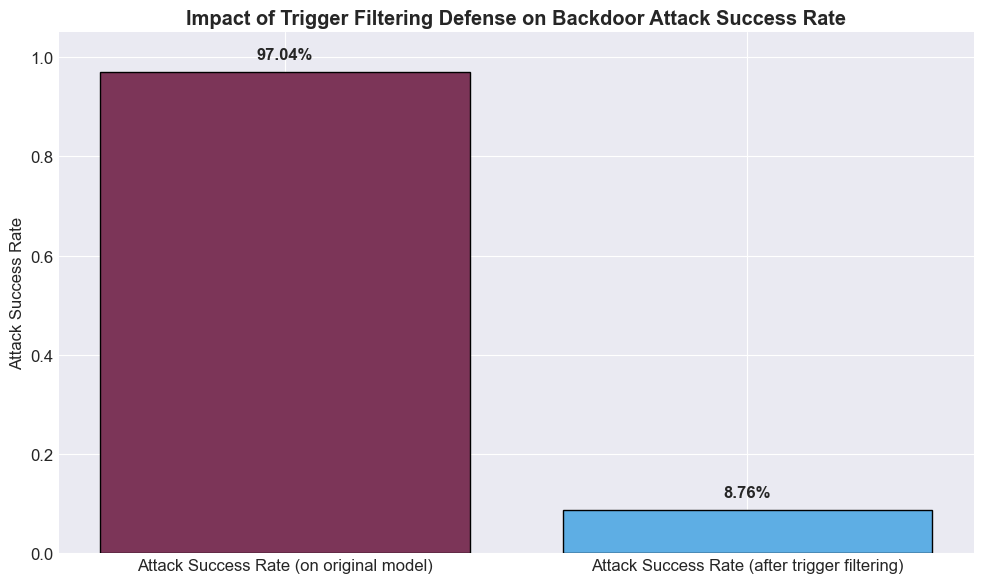

In [ ]:
# Data for plotting the requested two bars
labels = [
    "Attack Success Rate (on original model)",
    "Attack Success Rate (after trigger filtering)",
]
values = [asr, asr_filtered]
colors = ["#7c3558", "#5eaee4"]  # Red for attacked, Blue for defended

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, color=colors, edgecolor="black")

ax.set_ylim(0, 1.05)
ax.set_ylabel("Attack Success Rate")
ax.set_title(
    "Impact of Trigger Filtering Defense on Backdoor Attack Success Rate",
    fontweight="bold",
)

for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.02,
        f"{yval*100:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()